In [1]:
# This NoteBook is inspired by the work of Lai Yee, Ng and Friends (2022)
# Apex Frame Spotting Using Attention Networks
#
# This code is adapted from their proposed methods and modified for research purposes.
# My aim is to explore and experiment with the techniques presented in the paper.
# 
# My strategies:
# 1. Set-up dataset for apex frame spotting task
# 2. Determine facial landmarks using Mediapipe to focus on ROI
# 3. Implement Optical Flow to capture motion information between frames

print('Prosedurally generated code snippet executed successfully.')

Prosedurally generated code snippet executed successfully.


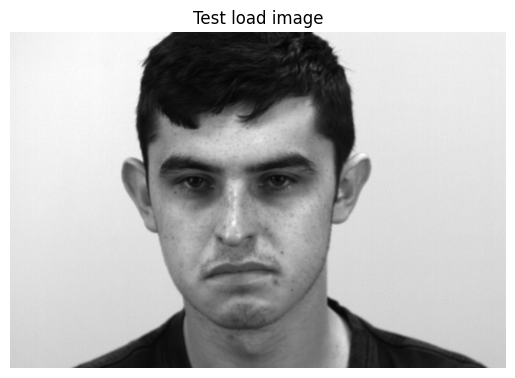

(Text(0.5, 1.0, 'Test load image'),
 (-0.5, 959.5, 649.5, -0.5),
 None)

In [1]:
# Setup the dataset for apex frame spotting task
import os
import re
import glob
import cv2
import matplotlib.pyplot as plt

DATASET_PATH = '/home/inadio/.undergrade-thesis/datasets/samm-i'

# Validate the dataset path should be exist
# Raise an assertion error if the path does not exist
assert os.path.exists(os.path.expanduser(DATASET_PATH)), "Dataset path does not exist."

# List all data files in the dataset list
files = glob.glob(os.path.join(DATASET_PATH, '**', '*.jpg'), recursive=True)
files.sort(key=lambda p: [int(i) if i.isdigit() else i.lower() for part in os.path.relpath(p, DATASET_PATH).split(os.sep) for i in re.split(r'(\d+)', part) if i])

image = cv2.imread(files[0])
plt.title('Test load image'), plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)), plt.axis('off'), plt.show()

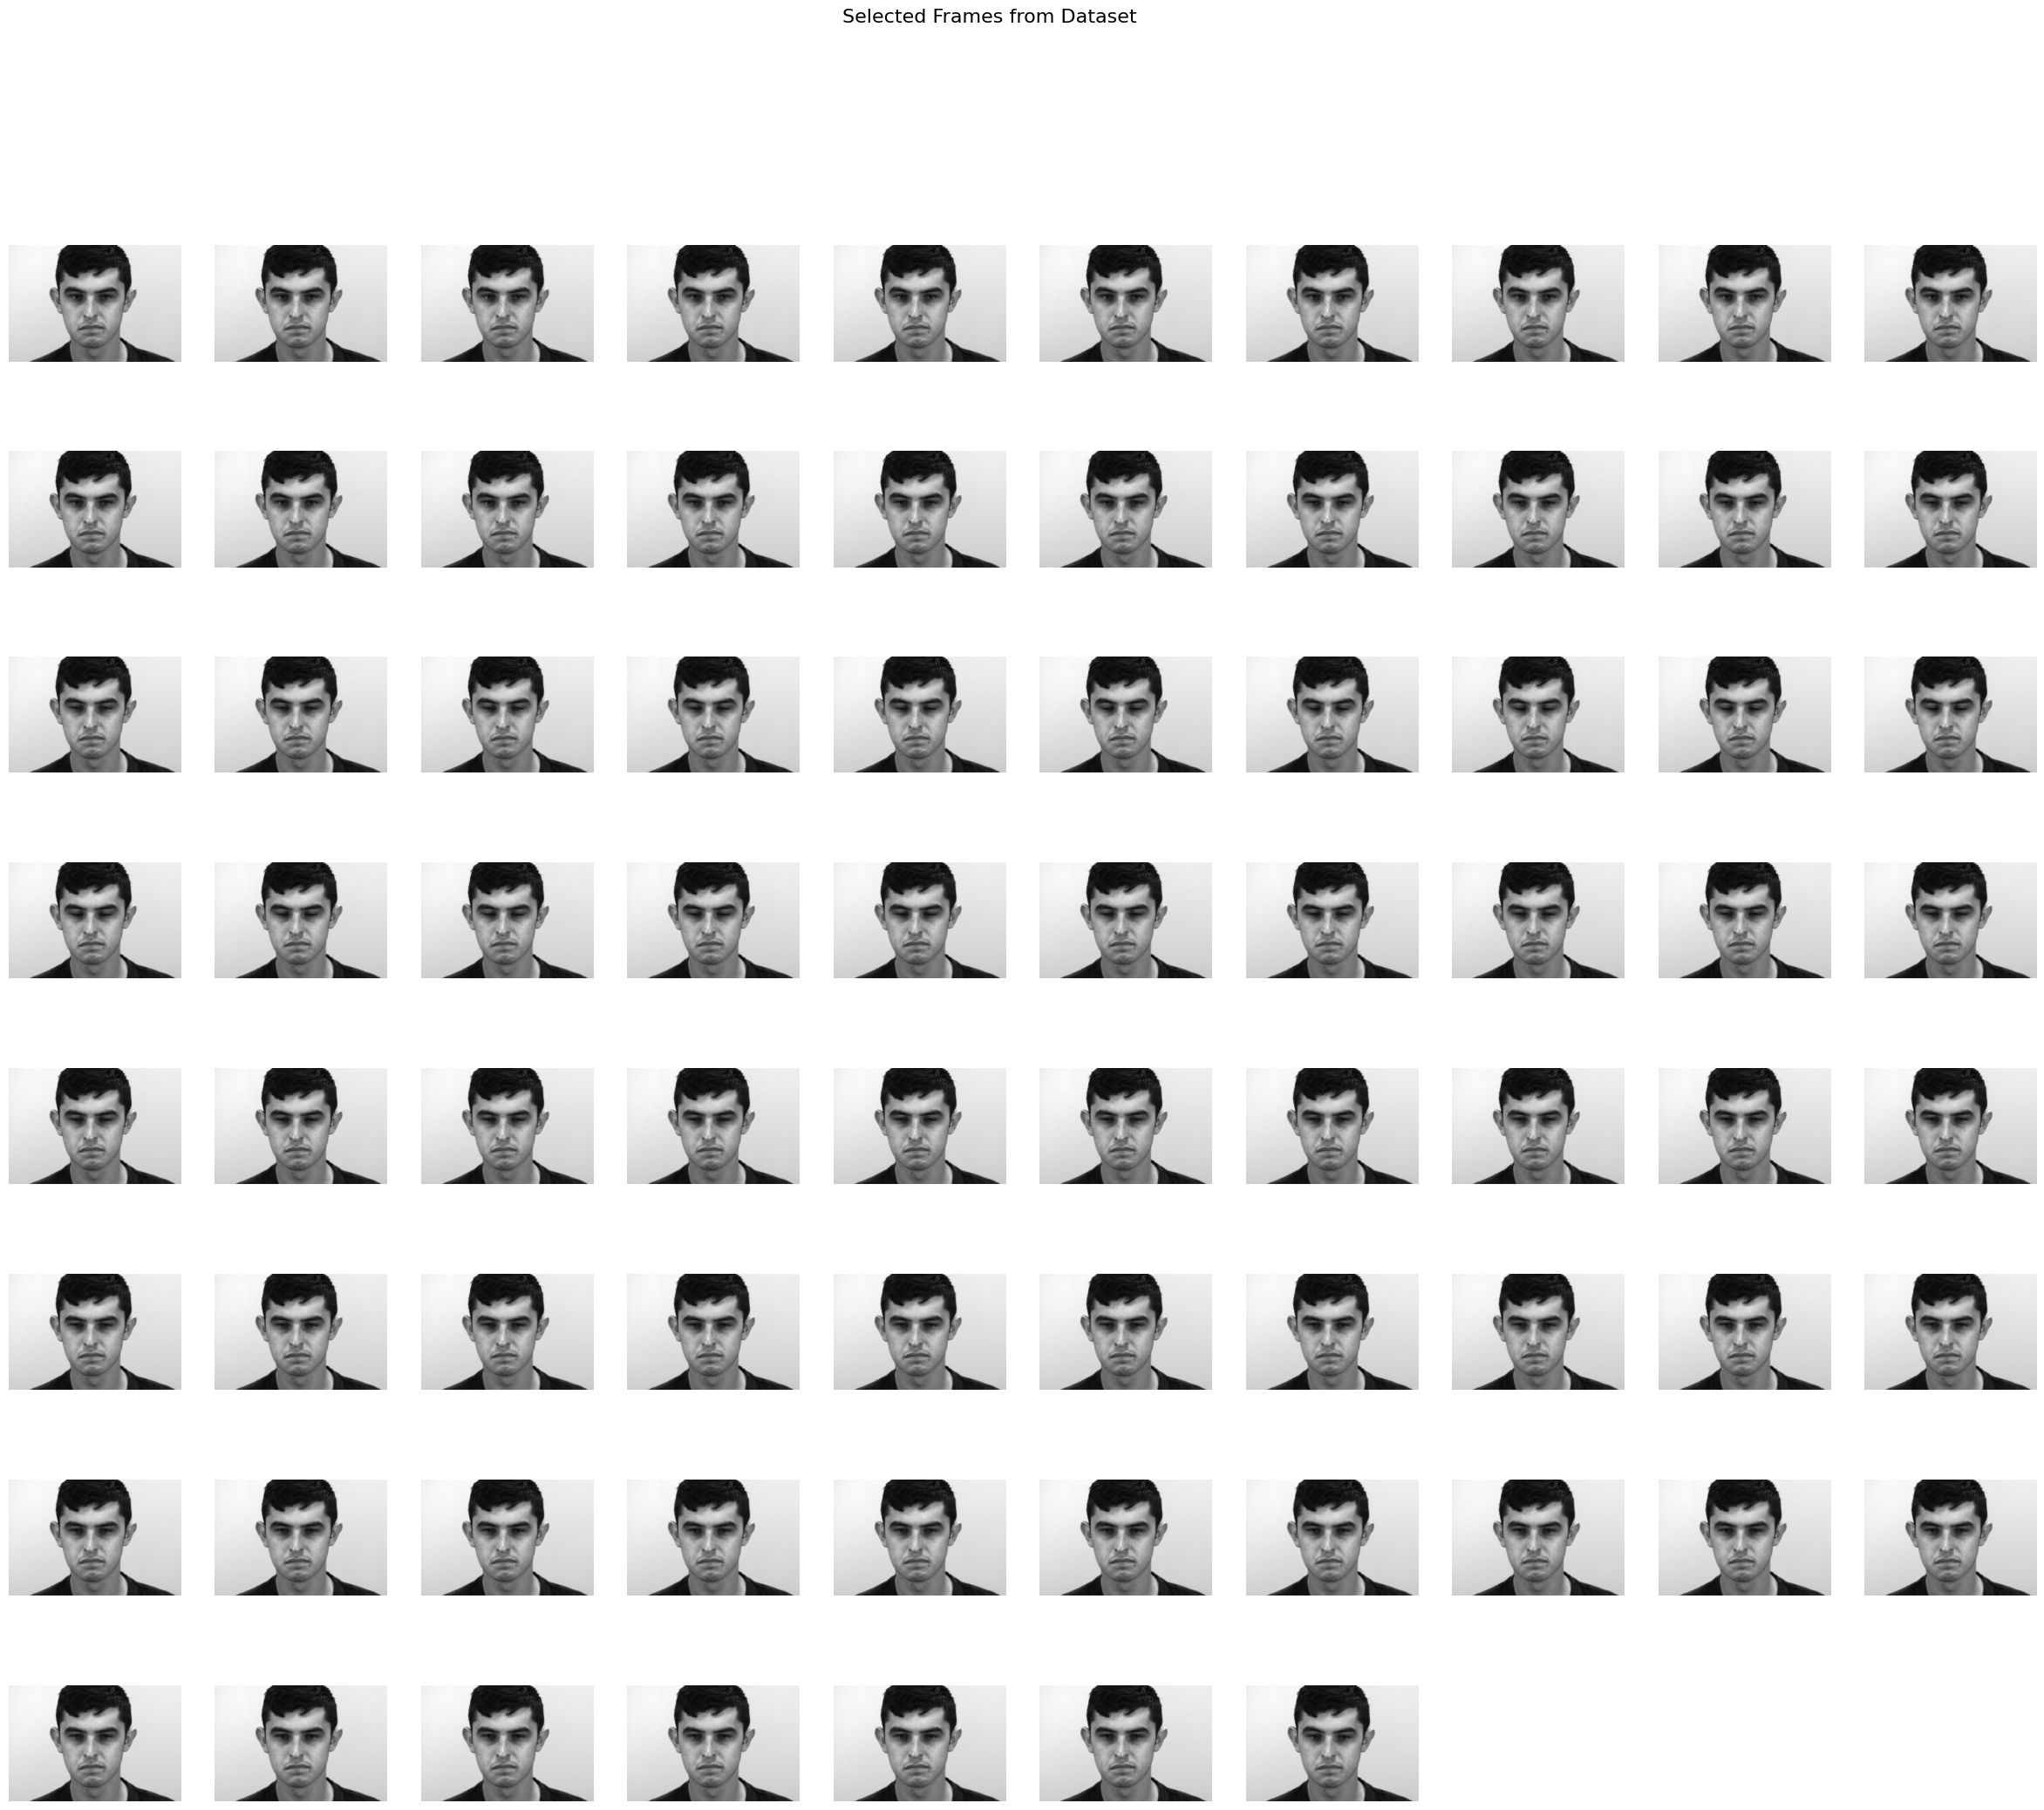

(Text(0.5, 0.98, 'Selected Frames from Dataset'), None)

In [2]:
import math
import matplotlib.pyplot as plt

# Define selected frames for apex frame spotting
selected_frames = files[72:149]

# Visualize selected frames
fig_cols = 10
fig_rows = math.ceil(len(selected_frames) / fig_cols)
fig = plt.figure(figsize=(fig_cols * 3, fig_rows * 3))
for i, frame_path in enumerate(selected_frames):
    img = cv2.imread(frame_path)
    ax = fig.add_subplot(fig_rows, fig_cols, i + 1)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.suptitle('Selected Frames from Dataset', fontsize=16), plt.show()

In [93]:
from mtcnn import MTCNN
    
    
def detect_and_crop_face(frame, detector):
    # Initialize MTCNN model to detect faces
    if detector is None:
        detector = MTCNN(device="CPU:0")
    
    # Detect face in the frame and crop the face region
    faces = detector.detect_faces(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    
    # If no face is detected, raise with an error
    if len(faces) == 0:
        raise RuntimeError("No face detected in the frame.")
    
    # Crop the first detected face
    x, y, w, h = faces[0]['box']
    x, y = max(0, x), max(0, y)

    w = max(1, min(w, frame.shape[1] - x))
    h = max(1, min(h, frame.shape[0] - y))
    
    # Crop and return the face region
    return frame[y:y+h, x:x+w]

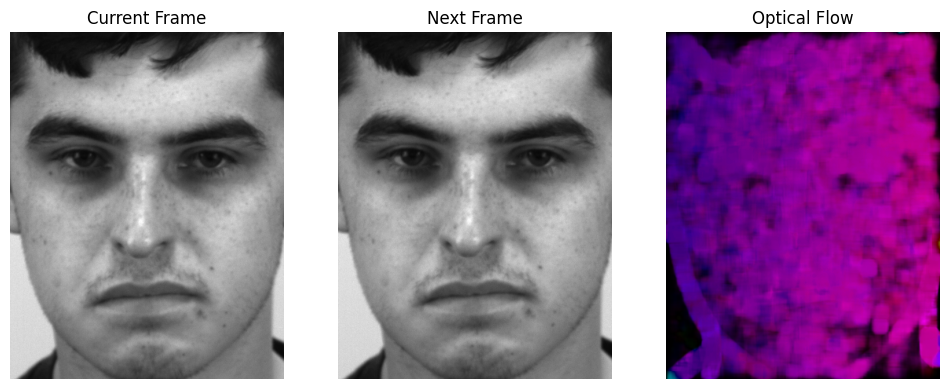

In [16]:
# Compute and visualize optical flow between consecutive frames
# Using Farneback method for dense optical flow estimation
#
# Magnitude formula: sqrt(dx^2 + dy^2)


import cv2
import numpy as np

frame1 = cv2.imread(selected_frames[0])
frame2 = cv2.imread(selected_frames[1])

roi_frame1 = detect_and_crop_face(frame1)
roi_frame2 = detect_and_crop_face(frame2)

prev_gray = cv2.cvtColor(roi_frame1, cv2.COLOR_BGR2GRAY)
next_gray = cv2.cvtColor(roi_frame2, cv2.COLOR_BGR2GRAY)

if prev_gray.shape != next_gray.shape:
    next_gray = cv2.resize(next_gray, (prev_gray.shape[1], prev_gray.shape[0]), interpolation=cv2.INTER_LINEAR)

flow = cv2.calcOpticalFlowFarneback(
    prev=prev_gray,
    next=next_gray,
    flow=None,
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)

hsv = np.zeros_like(frame1)
hsv[..., 1] = 255

mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
hsv = np.zeros((flow.shape[0], flow.shape[1], 3), dtype=np.uint8)
hsv[...,0] = ang * 180 / np.pi / 2
hsv[...,1] = 255
hsv[...,2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
flow_color = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.title('Current Frame'); plt.axis('off'); plt.imshow(cv2.cvtColor(roi_frame1, cv2.COLOR_BGR2RGB))
plt.subplot(1,3,2); plt.title('Next Frame');    plt.axis('off'); plt.imshow(cv2.cvtColor(roi_frame2, cv2.COLOR_BGR2RGB))
plt.subplot(1,3,3); plt.title('Optical Flow');plt.axis('off'); plt.imshow(cv2.cvtColor(flow_color, cv2.COLOR_BGR2RGB))
plt.show()

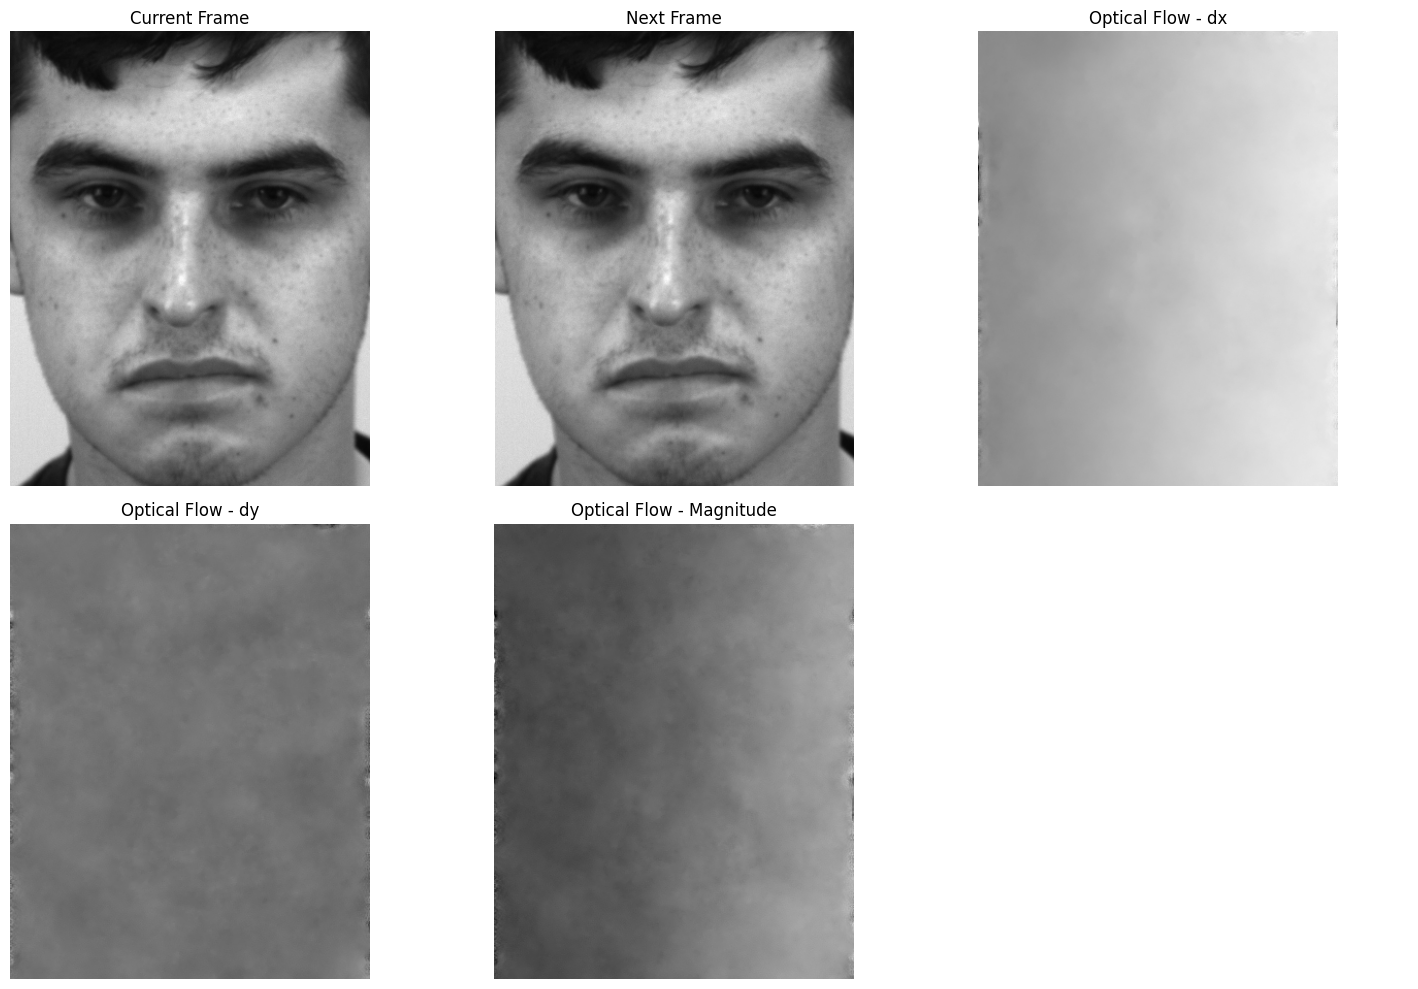

In [17]:
# Compute and visualize optical flow between consecutive frames
# Visualize the optical flow components (dx, dy)
# To show vector field on the horizontal and vertical directions

import cv2
import numpy as np

frame1 = cv2.imread(selected_frames[0])
frame2 = cv2.imread(selected_frames[1])

roi_frame1 = detect_and_crop_face(frame1)
roi_frame2 = detect_and_crop_face(frame2)

tvl1 = cv2.optflow.DualTVL1OpticalFlow_create()
prev_gray = cv2.cvtColor(roi_frame1, cv2.COLOR_BGR2GRAY)
next_gray = cv2.cvtColor(roi_frame2, cv2.COLOR_BGR2GRAY)

if prev_gray.shape != next_gray.shape:
    next_gray = cv2.resize(next_gray, (prev_gray.shape[1], prev_gray.shape[0]), interpolation=cv2.INTER_LINEAR)

flow = tvl1.calc(prev_gray, next_gray, None)

dx = flow[..., 0]
dy = flow[..., 1]
mag = np.sqrt(dx**2 + dy**2)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

image1 = cv2.cvtColor(roi_frame1, cv2.COLOR_BGR2RGB)
image2 = cv2.cvtColor(roi_frame2, cv2.COLOR_BGR2RGB)
image_dx = cv2.normalize(dx, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
image_dy = cv2.normalize(dy, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
image_mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

axes[0, 0].imshow(image1); axes[0, 0].set_title('Current Frame'); axes[0, 0].axis('off')
axes[0, 1].imshow(image2); axes[0, 1].set_title('Next Frame'); axes[0, 1].axis('off')
axes[0, 2].imshow(image_dx, cmap='gray'); axes[0, 2].set_title('Optical Flow - dx'); axes[0, 2].axis('off')
axes[1, 0].imshow(image_dy, cmap='gray'); axes[1, 0].set_title('Optical Flow - dy'); axes[1, 0].axis('off')
axes[1, 1].imshow(image_mag, cmap='gray'); axes[1, 1].set_title('Optical Flow - Magnitude'); axes[1, 1].axis('off')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

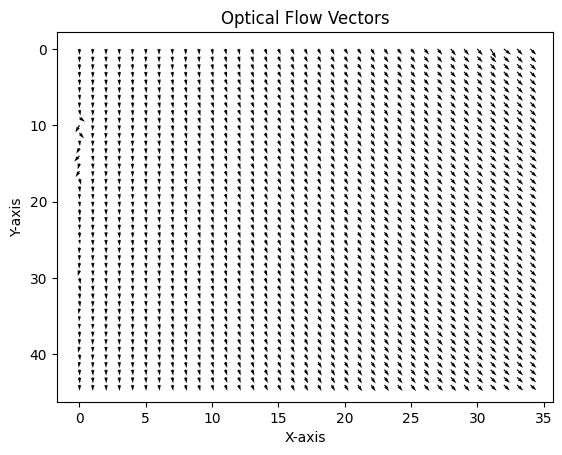

In [20]:
# Compute and visualize optical flow between consecutive frames
# Plotting optical flow vectors using quiver plot
# To show vector field using quiver plot

import cv2
import numpy as np
import matplotlib.pyplot as plt

frame1 = cv2.imread(selected_frames[0])
frame2 = cv2.imread(selected_frames[1])

roi_frame1 = detect_and_crop_face(frame1)
roi_frame2 = detect_and_crop_face(frame2)

prev_gray = cv2.cvtColor(roi_frame1, cv2.COLOR_BGR2GRAY)
next_gray = cv2.cvtColor(roi_frame2, cv2.COLOR_BGR2GRAY)
 
if prev_gray.shape != next_gray.shape:
    next_gray = cv2.resize(next_gray, (prev_gray.shape[1], prev_gray.shape[0]), interpolation=cv2.INTER_LINEAR)
    
tvl1 = cv2.optflow.DualTVL1OpticalFlow_create()
flow = tvl1.calc(prev_gray, next_gray, None)

plt.quiver(flow[::10, ::10, 0], flow[::10, ::10, 1])
plt.gca().invert_yaxis()
plt.title('Optical Flow Vectors')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()
    

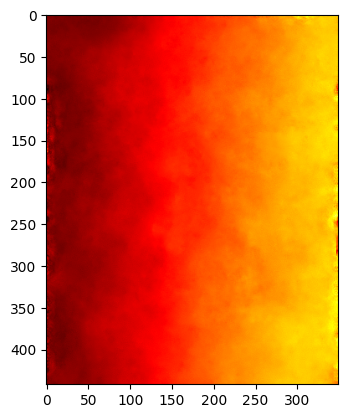

In [21]:
# Getting motion attention map 
# Seeing magnitude over the selected frames

tlv1 = cv2.optflow.DualTVL1OpticalFlow_create()

frame1 = cv2.imread(selected_frames[0])
frame2 = cv2.imread(selected_frames[1])

roi_frame1 = detect_and_crop_face(frame1)
roi_frame2 = detect_and_crop_face(frame2)

prev_gray = cv2.cvtColor(roi_frame1, cv2.COLOR_BGR2GRAY)
next_gray = cv2.cvtColor(roi_frame2, cv2.COLOR_BGR2GRAY)

if prev_gray.shape != next_gray.shape:
    next_gray = cv2.resize(next_gray, (prev_gray.shape[1], prev_gray.shape[0]), interpolation=cv2.INTER_LINEAR)
    
flow = tlv1.calc(prev_gray, next_gray, None)
    
motion_map = np.mean(np.abs(flow[..., :2]), axis=2)
plt.imshow(motion_map, cmap='hot')

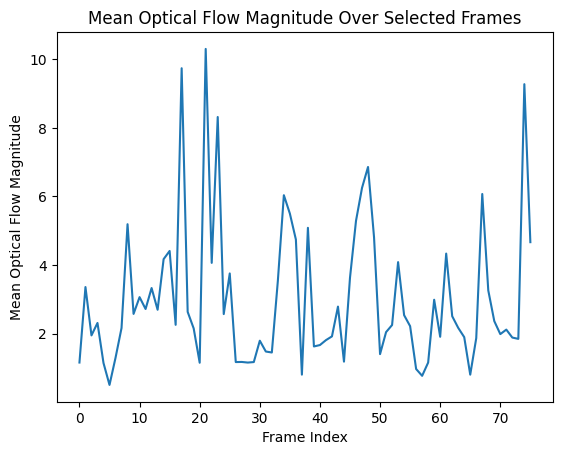

In [22]:
# Getting temporal magnitude curve based on optical flow

import cv2
import numpy as np
import matplotlib.pyplot as plt

magnitude_list = []
tlv1 = cv2.optflow.DualTVL1OpticalFlow_create()

for i in range(len(selected_frames) - 1):
    prev = cv2.imread(selected_frames[i])
    next = cv2.imread(selected_frames[i + 1])
    
    roi_prev = detect_and_crop_face(prev)
    roi_next = detect_and_crop_face(next)
    
    prev_gray = cv2.cvtColor(roi_prev, cv2.COLOR_BGR2GRAY)
    next_gray = cv2.cvtColor(roi_next, cv2.COLOR_BGR2GRAY)
    
    if prev_gray.shape != next_gray.shape:
        next_gray = cv2.resize(next_gray, (prev_gray.shape[1], prev_gray.shape[0]), interpolation=cv2.INTER_LINEAR)
        
    flow = tlv1.calc(prev_gray, next_gray, None)
    
    dx = flow[..., 0]
    dy = flow[..., 1]
    mag = np.sqrt(dx**2 + dy**2)
    
    mean_magnitude = np.mean(mag)
    magnitude_list.append(mean_magnitude)
    

plt.plot(magnitude_list)
plt.title('Mean Optical Flow Magnitude Over Selected Frames')
plt.xlabel('Frame Index')
plt.ylabel('Mean Optical Flow Magnitude')
plt.show()

The magnitude curve on the full face appears very noisy, with movement in each frame tending to be unstable, always showing sharp spikes and steep drops.

Assumptions for improvement can be made by focusing on the ROI (Region of Interest).
Take a specific ideal area, for example, focus on the eyebrows, eyes, cheeks, and mouth.

In addition to focusing on ROI, the next step can also implement RAFT as a technique for capturing optical flow. Based on the results of other researchers' research, RAFT tends to produce less noise, which may be quite suitable for the current case. However, focusing on ROI seems to be more important than using a new model.

In [ ]:
# Disabled mediapipe logging

import os
from absl import logging as absl_logging


os.environ['GLOG_minloglevel'] = '2'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
absl_logging.set_verbosity(absl_logging.ERROR)

I0000 00:00:1763646886.238839   18128 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1763646886.240304   26077 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.3-1ubuntu1), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1763646886.241998   26073 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763646886.253474   26071 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


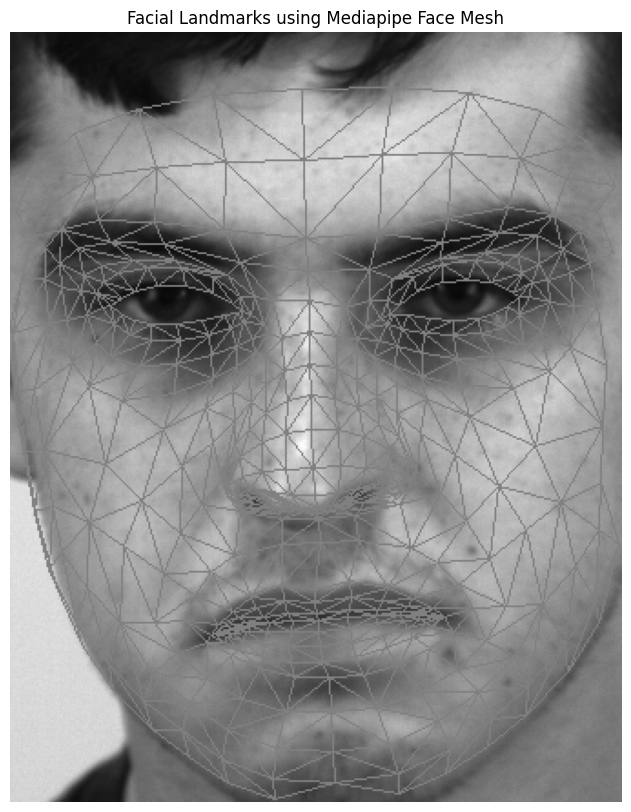

I0000 00:00:1763646886.425238   18128 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1763646886.426530   26088 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.3-1ubuntu1), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1763646886.447448   26085 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763646886.461960   26085 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [38]:
import mediapipe as mp


face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

frame = cv2.imread(selected_frames[0])
face = detect_and_crop_face(frame)

with face_mesh.FaceMesh(static_image_mode=True,
                       max_num_faces=1,
                       refine_landmarks=True,
                       min_detection_confidence=0.5) as face_mesh_model:
    results = face_mesh_model.process(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
    
    if results.multi_face_landmarks:
        annotated_image = face.copy()
        for face_landmarks in results.multi_face_landmarks:
            mp_drawing.draw_landmarks(
                image=annotated_image,
                landmark_list=face_landmarks,
                connections=face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_tesselation_style())
        
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('Facial Landmarks using Mediapipe Face Mesh')
        plt.show()
    else:
        print("No face landmarks detected.")
    face_mesh.FaceMesh().close()

Calculate optical flow magnitude based on selected ROI

The estimation is focused for each ROI

In [ ]:
# Regions of Interest
# Define regions of interest (ROIs) based on facial landmarks
# The selected ROIs based on FACS standarization
#
# https://imotions.com/blog/learning/research-fundamentals/facial-action-coding-system

ROIs = {
    "Upper Left": [
        70, 63, 105, 66, 107,   # Left Eye Brow
        33, 133, 159, 145, 153, # Left Eye
    ],
    
    "Upper Right": [
        336, 296, 334, 293, 300,   # Right Eye Brow
        362, 263, 386, 374, 380,   # Right Eye
    ],
    
    "Lower Face": [
        61,146,91,181,84,17,314,405,321,375,291,   # Mouth Region
        78,95,88,178,191,80,81,82,                 # Nose Region
        50,101,118,120,49,                         # Chin Region
        278,347,330,329,348                        # Jawline Region
    ]
}

# Stable indices for facial landmarks
# These indices are choosen to represent stable points on the face
# that are less affected by facial expressions and movements.
#
# These points information are inspired by:
# https://arxiv.org/pdf/1907.05047

STABLE_INDICES = [1, 33, 61, 199, 263, 291, 152]

Slicing Regions of Interest From Selected Frame Sequence

In [6]:
# Utils
import cv2
import numpy as np
import matplotlib.pyplot as plt


def crop_roi_from_mask(image, mask):
    masked = cv2.bitwise_and(image, image, mask=mask)
    
    ys, xs = np.where(mask == 255)
    if len(xs) == 0 or len(ys) == 0:
        return None
    
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    
    return masked[y_min:y_max+1, x_min:x_max+1]


def extract_points(indices, landmarks, w, h):
    return np.array([(
                    int(landmarks.landmark[idx].x * w),
                    int(landmarks.landmark[idx].y * h))

        for idx in indices
    ])


def create_roi_mask(pts, shape):
    mask = np.zeros(shape[:2], dtype=np.uint8)
    hull = cv2.convexHull(pts)
    cv2.fillConvexPoly(mask, hull, 255)
    return hull, mask


def create_plot_quiver_roi(frame, flow, mask, name, step=4, scale=3):
    masked_flow = cv2.bitwise_and(flow, flow, mask=mask)
    y_indices, x_indices = np.where(mask == 255)

    if len(x_indices) == 0 or len(y_indices) == 0:
        return

    x_min, x_max = x_indices.min(), x_indices.max()
    y_min, y_max = y_indices.min(), y_indices.max()

    roi_flow = masked_flow[y_min : y_max + 1, x_min : x_max + 1]
    roi_frame = frame[y_min : y_max + 1, x_min : x_max + 1]

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(roi_frame, cv2.COLOR_BGR2RGB))

    h, w = roi_flow.shape[:2]
    
    X, Y = np.meshgrid(
        np.arange(0, w, step),
        np.arange(0, h, step),
    )

    U = roi_flow[::step, ::step, 0]
    V = roi_flow[::step, ::step, 1]

    plt.quiver(X, Y, U, V, color="r", angles="xy", scale_units="xy", scale=1/scale, width=0.005)
    plt.title(f"Optical Flow Vectors: {name}")
    plt.axis("off")
    plt.show()

In [7]:
import cv2
import numpy as np


def align_face(image, landmarks_ref, landmarks_current, width, height, indices=STABLE_INDICES):
    pts_ref = np.float32([[landmarks_ref.landmark[i].x * width, landmarks_ref.landmark[i].y * height] for i in indices])
    pts_curr = np.float32([[landmarks_current.landmark[i].x * width, landmarks_current.landmark[i].y * height] for i in indices])
    
    matrix, _ = cv2.estimateAffinePartial2D(pts_curr, pts_ref)
    if matrix is None:
        raise RuntimeError("Could not estimate affine transformation.")
    
    aligned_face = cv2.warpAffine(image, matrix, (width, height))
    return aligned_face

I0000 00:00:1763727279.879150    7494 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1763727279.881719   11863 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.3-1ubuntu1), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1763727279.887374   11853 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763727279.906133   11859 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


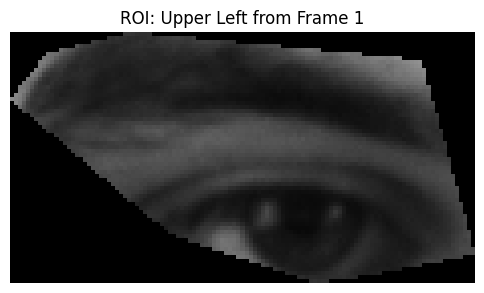

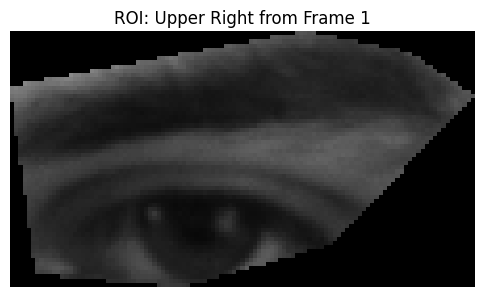

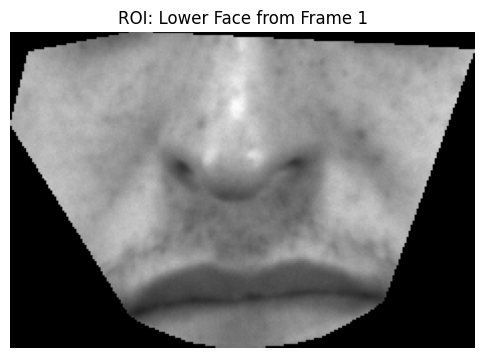

In [ ]:
# Slice the selected ROIs from current selected frame
# Using Mediapipe Face Mesh to determine facial landmarks


import cv2
import mediapipe as mp

face_mesh = mp.solutions.face_mesh
face_mesh_model = face_mesh.FaceMesh(static_image_mode=True,
                                     max_num_faces=1,
                                     refine_landmarks=True,
                                     min_detection_confidence=0.5)



frame_one = detect_and_crop_face(cv2.imread(selected_frames[0]))

for roi_key, roi_landmark_points in ROIs.items():
    
    res_one = face_mesh_model.process(cv2.cvtColor(frame_one, cv2.COLOR_BGR2RGB))
    
    if res_one.multi_face_landmarks:
        landmarks_one = res_one.multi_face_landmarks[0]
        
        w1, h1 = frame_one.shape[1], frame_one.shape[0]
        
        pts_one = extract_points(roi_landmark_points, landmarks_one, w1, h1)

        _, mask_one = create_roi_mask(pts_one, frame_one.shape)
        
        roi_image_one = crop_roi_from_mask(frame_one, mask_one)
        
        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(roi_image_one, cv2.COLOR_BGR2RGB))
        plt.title(f'ROI: {roi_key} from Frame 1')
        plt.axis('off')
        plt.show()
        

face_mesh_model.close()

Calculating optical flow magnitude based on the selected frames

Using TVL1 as the model to retrieve optical flow



In [ ]:
# Prepare the TVL1 optical flow model

import cv2
import torch


class TVL1OpticalFlow:
    def __init__(self):
        self.tvl1 = cv2.optflow.DualTVL1OpticalFlow_create()
        
        # Tuning for better motion estimation
        self.tvl1.setLambda(0.15)
        self.tvl1.setTheta(0.3)
        self.tvl1.setTau(0.25)
        self.tvl1.setScaleStep(0.8)
        self.tvl1.setWarpingsNumber(5)
    

    def compute_flow(self, prev, next):   
        if isinstance(prev, (tuple, list)):
            prev = prev[0]
        if isinstance(next, (tuple, list)):
            next = next[0]
            
        if isinstance(prev, torch.Tensor):
            prev = prev.squeeze(0).cpu().numpy()
        if isinstance(next, torch.Tensor):
            next = next.squeeze(0).cpu().numpy()
            
        if prev.ndim == 3:
            if prev.shape[0] == 1:
                prev = prev[0]
            elif prev.shape[2] == 3:
                prev = cv2.cvtColor(prev.astype(np.float32), cv2.COLOR_RGB2GRAY)
            else:
                prev = cv2.cvtColor(np.transpose(prev, (1, 2, 0)).astype(np.float32), cv2.COLOR_RGB2GRAY)

        if next.ndim == 3:
            if next.shape[0] == 1:
                next = next[0]
            elif next.shape[2] == 3:
                next = cv2.cvtColor(next.astype(np.float32), cv2.COLOR_RGB2GRAY)
            else:
                next = cv2.cvtColor(np.transpose(next, (1, 2, 0)).astype(np.float32), cv2.COLOR_RGB2GRAY)

        prev = prev.astype(np.float32)
        next = next.astype(np.float32)

        if prev.shape != next.shape:
            next = cv2.resize(next, (prev.shape[1], prev.shape[0]), interpolation=cv2.INTER_LINEAR)

        flow = self.tvl1.calc(prev, next, None)
        return flow

I0000 00:00:1763789196.190596   20405 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1763789196.192671   21372 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.3-1ubuntu1), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1763789196.197158   21363 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763789196.210494   21368 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


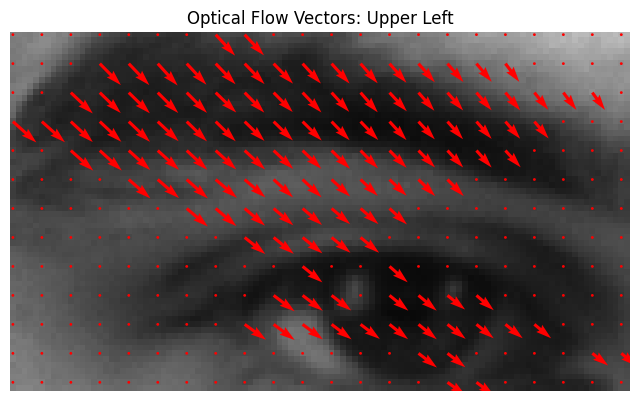

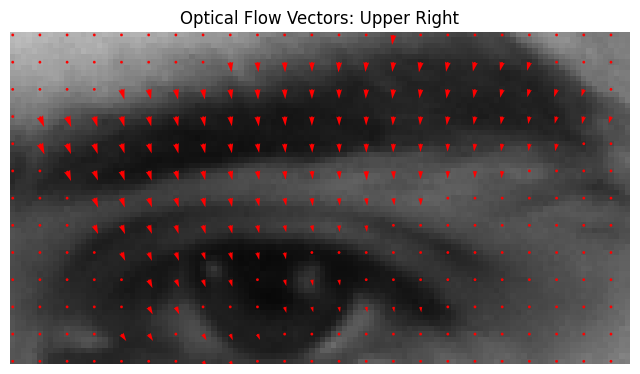

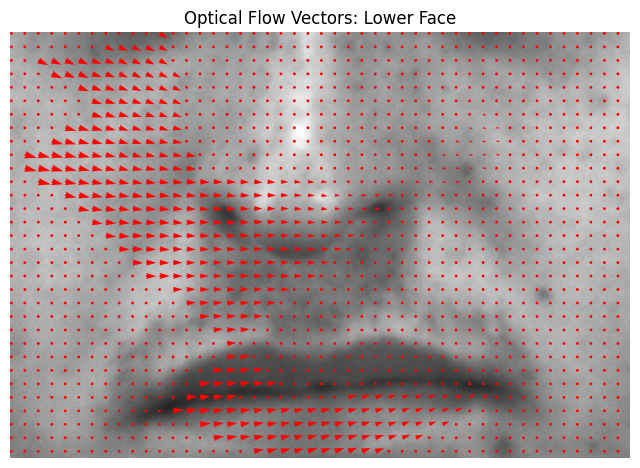

In [15]:
# Test: Compute optical flow on ROI between two frames

import numpy as np
import mediapipe as mp


tvl1_model = TVL1OpticalFlow()

face_mesh = mp.solutions.face_mesh
face_mesh_model = mp.solutions.face_mesh.FaceMesh(static_image_mode=True,
                                                  max_num_faces=1,
                                                  refine_landmarks=True,
                                                  min_detection_confidence=0.5)

frame1 = cv2.imread(selected_frames[0])
frame2 = cv2.imread(selected_frames[1])

origin_height, origin_width = frame1.shape[:2]

res_lm1 = face_mesh_model.process(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
res_lm2 = face_mesh_model.process(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))

if res_lm1.multi_face_landmarks and res_lm2.multi_face_landmarks:
    lm1 = res_lm1.multi_face_landmarks[0]
    lm2 = res_lm2.multi_face_landmarks[0]
    
    frame2_aligned = align_face(frame2, lm1, lm2, origin_width, origin_height)
    
    prev_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    next_gray = cv2.cvtColor(frame2_aligned, cv2.COLOR_BGR2GRAY)
    
    flow = tvl1_model.compute_flow(prev_gray, next_gray)
    
    for roi_key, roi_landmark_points in ROIs.items():
        pts = np.array([
            [int(lm1.landmark[idx].x * origin_width), int(lm1.landmark[idx].y * origin_height)] 
            for idx in roi_landmark_points
        ])
        
        mask = np.zeros((origin_height, origin_width), dtype=np.uint8)
        cv2.fillPoly(mask, [pts], 1)
        
        create_plot_quiver_roi(frame1, flow, mask*255, roi_key, step=5, scale=5)

Spot Apex frame based on the selected frames with TVL1 optical flow calculator

I0000 00:00:1763794838.829852   20405 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1763794838.835464   29818 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.3-1ubuntu1), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1763794838.851130   29812 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763794838.874376   29809 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Apex Frame Index: 35
Apex Intensity: 9.3918


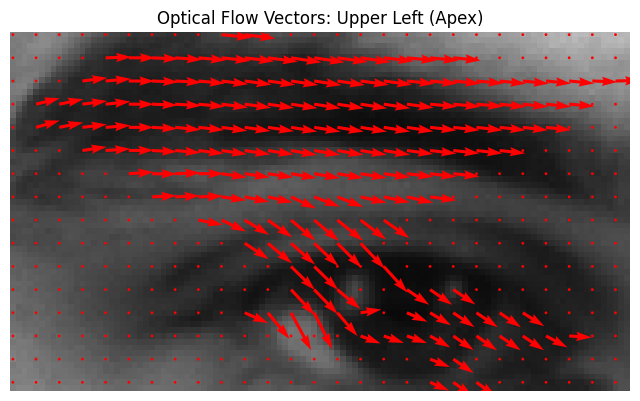

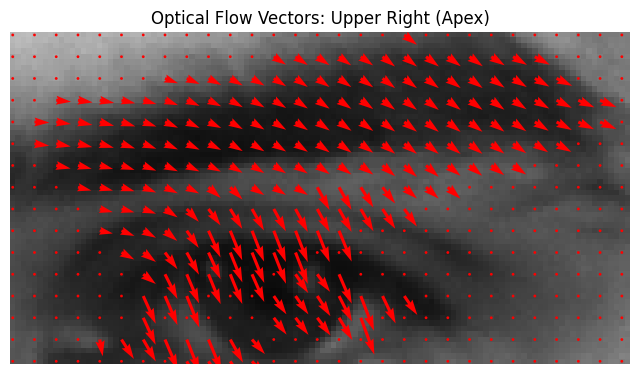

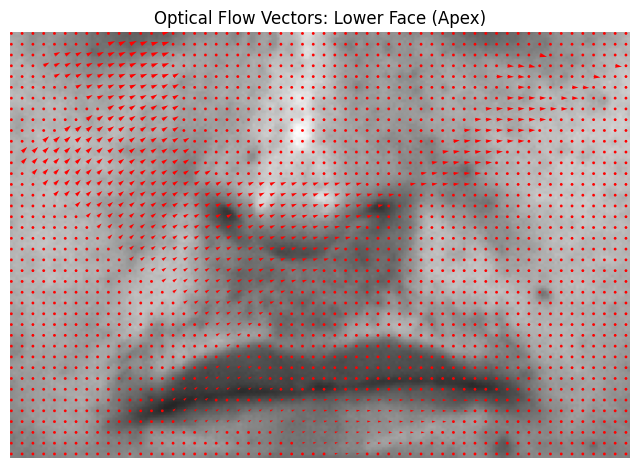

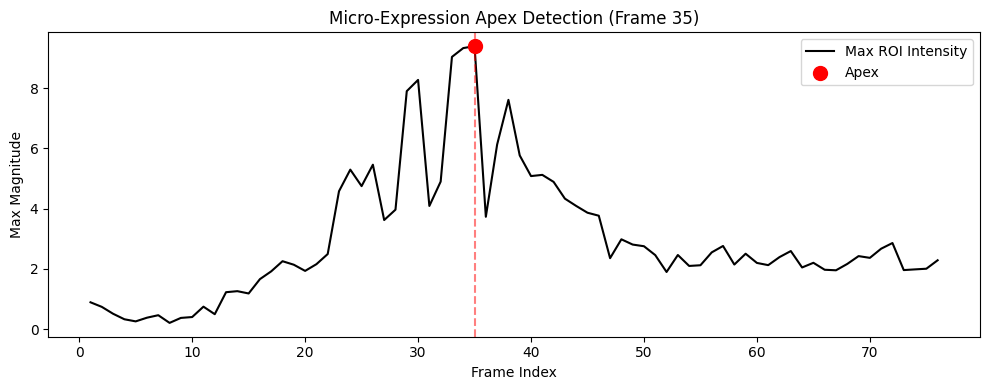

In [18]:
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt

os.environ["GLOG_minloglevel"] = "2"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

face_mesh = mp.solutions.face_mesh
face_mesh_model = mp.solutions.face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
)

tvl1_model = TVL1OpticalFlow()

if len(selected_frames) < 2:
    raise RuntimeError("Insufficient frames selected")

ref_frame = cv2.imread(selected_frames[0])
ref_height, ref_width = ref_frame.shape[:2]
ref_face_mesh_results = face_mesh_model.process(cv2.cvtColor(ref_frame, cv2.COLOR_BGR2RGB))

if not ref_face_mesh_results.multi_face_landmarks:
    raise RuntimeError("No face detected in the reference frame.")

ref_landmarks = ref_face_mesh_results.multi_face_landmarks[0]
frame_magnitudes = []

for i in range(1, len(selected_frames)):
    curr_frame = cv2.imread(selected_frames[i])
    if curr_frame is None:
        frame_magnitudes.append(0.0)
        continue

    res_curr = face_mesh_model.process(cv2.cvtColor(curr_frame, cv2.COLOR_BGR2RGB))
    
    if not res_curr.multi_face_landmarks:
        frame_magnitudes.append(0.0)
        continue

    curr_landmarks = res_curr.multi_face_landmarks[0]
    
    curr_aligned = align_face(
        curr_frame, 
        ref_landmarks, 
        curr_landmarks, 
        ref_width, 
        ref_height
    )
    
    flow = tvl1_model.compute_flow(ref_frame, curr_aligned)
    
    roi_intensities = []
    
    for _, indices in ROIs.items():
        pts = np.array([
            [int(ref_landmarks.landmark[idx].x * ref_width), 
             int(ref_landmarks.landmark[idx].y * ref_height)]
            for idx in indices
        ])
        
        mask = np.zeros((ref_height, ref_width), dtype=np.uint8)
        cv2.fillPoly(mask, [pts], 1)
        
        flow_roi = flow[mask == 1]
        
        if len(flow_roi) > 0:
            mag = np.sqrt(flow_roi[:, 0]**2 + flow_roi[:, 1]**2)
            roi_intensities.append(np.mean(mag))
        else:
            roi_intensities.append(0.0)
            
    frame_score = np.max(roi_intensities) if len(roi_intensities) > 0 else 0.0
    frame_magnitudes.append(frame_score)

apex_idx = np.argmax(frame_magnitudes) + 1 
apex_val = np.max(frame_magnitudes)

print(f"Apex Frame Index: {apex_idx}")
print(f"Apex Intensity: {apex_val:.4f}")

apex_frame_path = selected_frames[apex_idx]
apex_frame = cv2.imread(apex_frame_path)

res_apex = face_mesh_model.process(cv2.cvtColor(apex_frame, cv2.COLOR_BGR2RGB))

if res_apex.multi_face_landmarks:
    lm_apex = res_apex.multi_face_landmarks[0]
    apex_aligned = align_face(apex_frame, ref_landmarks, lm_apex, ref_width, ref_height)
    
    flow_apex = tvl1_model.compute_flow(ref_frame, apex_aligned)
    
    for roi_key, roi_indices in ROIs.items():
        pts = np.array([
            [int(ref_landmarks.landmark[idx].x * ref_width), 
             int(ref_landmarks.landmark[idx].y * ref_height)]
            for idx in roi_indices
        ])
        
        mask = np.zeros((ref_height, ref_width), dtype=np.uint8)
        cv2.fillPoly(mask, [pts], 255)
        
        create_plot_quiver_roi(
            ref_frame, 
            flow_apex, 
            mask, 
            f"{roi_key} (Apex)", 
            step=4, 
            scale=0.5
        )

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(selected_frames)), frame_magnitudes, label='Max ROI Intensity', color='black')
plt.scatter(apex_idx, apex_val, color='red', s=100, zorder=5, label='Apex')
plt.axvline(x=apex_idx, color='red', linestyle='--', alpha=0.5)
plt.title(f'Micro-Expression Apex Detection (Frame {apex_idx})')
plt.xlabel('Frame Index')
plt.ylabel('Max Magnitude')
plt.legend()
plt.tight_layout()
plt.show()

face_mesh_model.close()

Getting the peak magnitude mean from selected ROIs

In [38]:
# Creating RAFT blueprint model

import torch
from torchvision.models.optical_flow import raft_large, Raft_Large_Weights


class RAFT():
    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        self.weights = Raft_Large_Weights.DEFAULT
        self.transform = self.weights.transforms()
        self.model = raft_large(weights=self.weights, progress=False).to(self.device).eval()
        self.model.eval()    
    

    def compute_flow(self, prev, next):
        if prev.device != self.device:
            prev = prev.to(self.device)
        if next.device != self.device:
            next = next.to(self.device)
            
        with torch.no_grad():
            flows = self.model(prev, next)
            return flows[-1][0]

In [54]:
# Utilities for RAFT model (pre-processing)

import cv2
import numpy as np
import torchvision.transforms.functional as F


def raft_resize_and_pad(frame, padding=8, target_width=480):
    height, width = frame.shape[:2]
    scale = target_width / width
    new_width = target_width
    new_height = int(height * scale)
    
    resized = cv2.resize(frame, (new_width, new_height), interpolation=cv2.INTER_LINEAR)
    
    padding_height = (padding - new_height % padding) % padding
    padding_width = (padding - new_width % padding) % padding
    
    padded = np.pad(resized, ((0, padding_height), (0, padding_width), (0, 0)), mode='constant', constant_values=0)
    
    tensor = F.to_tensor(padded).unsqueeze(0)
    return tensor, scale


def align_frame_face(frame, lm_ref, lm_current, width, height):
    points_ref = np.float32([[lm_ref.landmark[idx].x * width, lm_ref.landmark[idx].y * height] for idx in STABLE_INDICES])
    points_current = np.float32([[lm_current.landmark[idx].x * width, lm_current.landmark[idx].y * height] for idx in STABLE_INDICES])
    
    M, _ = cv2.estimateAffinePartial2D(points_current, points_ref)
    
    if M is not None:
        return cv2.warpAffine(frame, M, (width, height))

    return frame

I0000 00:00:1763737632.825344   22665 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1763737632.826633   24559 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.3-1ubuntu1), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1763737632.829826   24555 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763737632.841042   24551 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


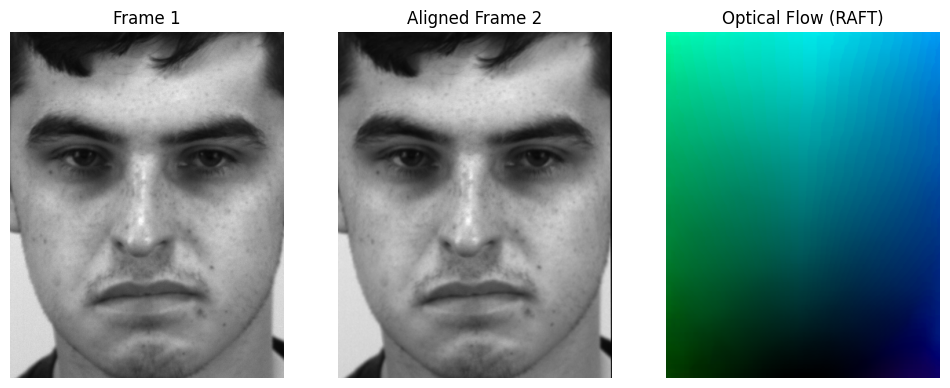

In [11]:
# Test: Implement RAFT optical flow for 2 consecutive frames
# Test: Try to align face using mediapipe landmarks for better performance


import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp


frame1 = detect_and_crop_face(cv2.imread(selected_frames[0]))
frame2 = detect_and_crop_face(cv2.imread(selected_frames[1]))

face_mesh = mp.solutions.face_mesh
face_mesh_model = face_mesh.FaceMesh(static_image_mode=True,
                                     max_num_faces=1,
                                     refine_landmarks=True,
                                     min_detection_confidence=0.5)

res1 = face_mesh_model.process(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
res2 = face_mesh_model.process(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))

if res1.multi_face_landmarks and res2.multi_face_landmarks:
    landmarks1 = res1.multi_face_landmarks[0]
    landmarks2 = res2.multi_face_landmarks[0]
    
    w1, h1 = frame1.shape[1], frame1.shape[0]
    w2, h2 = frame2.shape[1], frame2.shape[0]
    
    aligned_frame2 = align_frame_face(frame2, landmarks1, landmarks2, w1, h1)
    
    raft_model = RAFT()
    
    tensor1, scale1 = raft_resize_and_pad(frame1)
    tensor2, scale2 = raft_resize_and_pad(aligned_frame2)
    
    flow = raft_model.compute_flow(tensor1, tensor2)
    
    flow_np = flow.permute(1, 2, 0).cpu().numpy()
    
    mag, ang = cv2.cartToPolar(flow_np[...,0], flow_np[...,1])
    hsv = np.zeros((flow_np.shape[0], flow_np.shape[1], 3), dtype=np.uint8)
    hsv[...,0] = ang * 180 / np.pi / 2
    hsv[...,1] = 255
    hsv[...,2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    flow_color = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    
    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1); plt.title('Frame 1'); plt.axis('off'); plt.imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
    plt.subplot(1,3,2); plt.title('Aligned Frame 2'); plt.axis('off'); plt.imshow(cv2.cvtColor(aligned_frame2, cv2.COLOR_BGR2RGB))
    plt.subplot(1,3,3); plt.title('Optical Flow (RAFT)'); plt.axis('off'); plt.imshow(cv2.cvtColor(flow_color, cv2.COLOR_BGR2RGB))
    plt.show()

In [13]:
# Apex phase analysis from RAFT optical flow magnitudes

import numpy as np
from scipy.signal import savgol_filter


def analyze_phase(signal, noise_threshold=0.15):
    if (len(signal) == 7): return None
    
    y_smooth = savgol_filter(signal, window_length=7, polyorder=3)
    y_smooth[y_smooth < 0] = 0
    
    apex_index = np.argmax(y_smooth)
    apex_value = y_smooth[apex_index]
    
    if apex_value < noise_threshold: return None
    
    cutoff_value = apex_value * 0.35
    
    onset_index = 0
    for i in range(apex_index, 0, -1):
        if y_smooth[i] <= cutoff_value:
            onset_index = i
            break
        
        if i < apex_index - 1 and y_smooth[i] < y_smooth[i+1] and y_smooth[i] < y_smooth[i-1]:
            onset_index = i
            break
        
    
    offset_index = len(y_smooth) - 1
    for i in range(apex_index, len(y_smooth) -1):
        if y_smooth[i] <= cutoff_value:
            offset_index = i
            break
        if i > apex_index + 1 and y_smooth[i] < y_smooth[i-1] and y_smooth[i] < y_smooth[i+1]:
            offset_index = i
            break
        
    
    return {
        "onset": onset_index, 
        "apex": apex_index, 
        "offset": offset_index, 
        "intensity": apex_value,
        "smoothed_signal": y_smooth
    }

I0000 00:00:1763766095.935987   22665 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1763766095.958175   55158 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.3-1ubuntu1), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1763766095.972131   55155 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763766095.983853   55151 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


ROI: Upper Left
  Onset Frame: 31
  Apex Frame: 33
  Offset Frame: 43
  Intensity: 6.6728


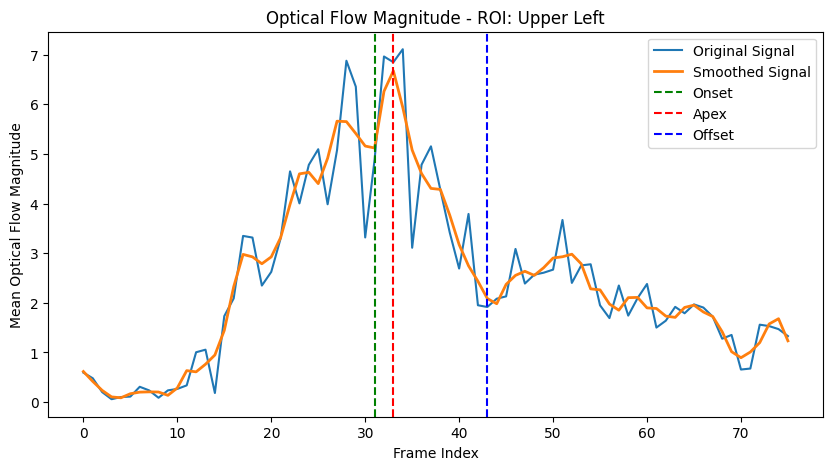

ROI: Upper Right
  Onset Frame: 31
  Apex Frame: 33
  Offset Frame: 44
  Intensity: 6.4725


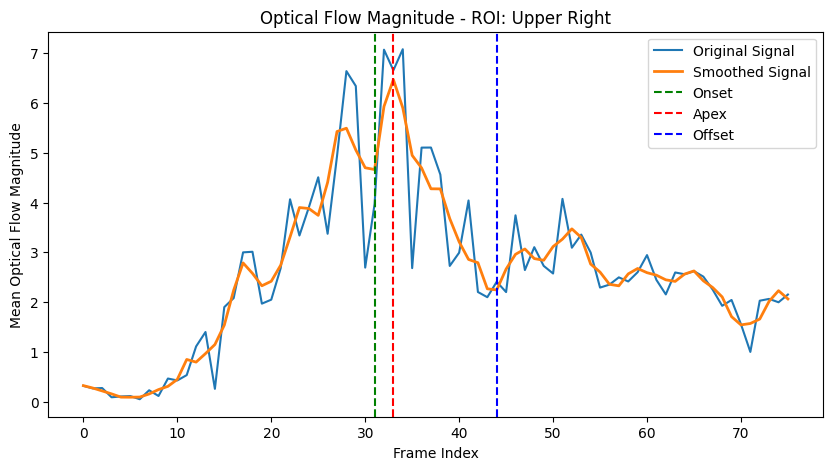

ROI: Lower Face
  Onset Frame: 28
  Apex Frame: 33
  Offset Frame: 44
  Intensity: 3.6393


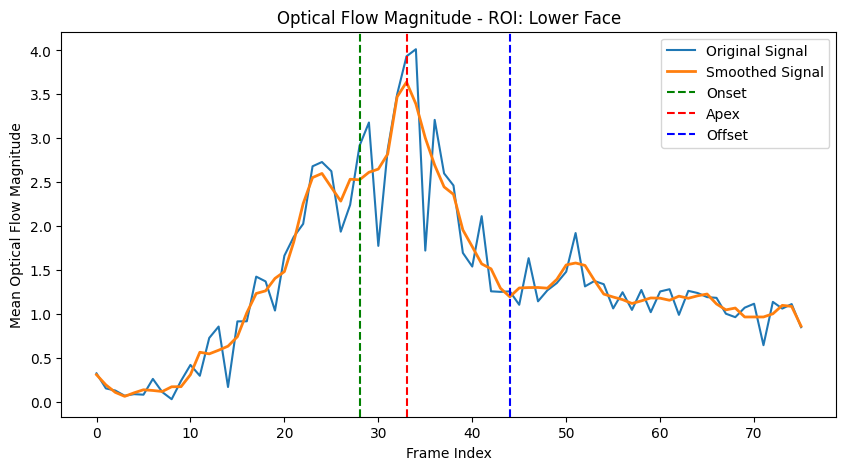

In [ ]:
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt

os.environ['GLOG_minloglevel'] = '2'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

raft = RAFT()

face_mesh               = mp.solutions.face_mesh
face_mesh_model         = face_mesh.FaceMesh(static_image_mode=True,
                                     max_num_faces=1,
                                     refine_landmarks=True,
                                     min_detection_confidence=0.5)

magnitude_list = {k: [] for k in ROIs.keys()}

ref_frame               = cv2.imread(selected_frames[0])
ref_rgb                 = cv2.cvtColor(ref_frame, cv2.COLOR_BGR2RGB)
ref_height, ref_width   = ref_frame.shape[:2]

ref_results = face_mesh_model.process(ref_rgb)

if not ref_results.multi_face_landmarks:
    raise RuntimeError("No face detected in the reference frame.")

ref_landmarks           = ref_results.multi_face_landmarks[0]
ref_tensor, scale       = raft_resize_and_pad(ref_frame)
ref_tensor              = 2 * (ref_tensor / 255.0) - 1.0

for frame in selected_frames[1:]:
    current_frame = cv2.imread(frame)
    if current_frame is None: continue
    
    curr_rgb = cv2.cvtColor(current_frame, cv2.COLOR_BGR2RGB)
    res_curr = face_mesh_model.process(curr_rgb)
    
    if not res_curr.multi_face_landmarks:
        for k in magnitude_list:
            magnitude_list[k].append(0.0)
        continue
        
    curr_landmarks = res_curr.multi_face_landmarks[0]
    
    aligned_curr = align_frame_face(current_frame, ref_landmarks, curr_landmarks, ref_width, ref_height)
    
    curr_tensor, _ = raft_resize_and_pad(aligned_curr)
    curr_tensor = 2 * (curr_tensor / 255.0) - 1.0
    
    flow = raft.compute_flow(ref_tensor, curr_tensor)
    flow_np = flow.permute(1, 2, 0).cpu().numpy()
    
    for roi_key, roi_indices in ROIs.items():
        pts = np.array([
            [int(ref_landmarks.landmark[idx].x * ref_width * scale), 
             int(ref_landmarks.landmark[idx].y * ref_height * scale)] 
            for idx in roi_indices
        ])
        
        mask = np.zeros(flow_np.shape[:2], dtype=np.uint8)
        cv2.fillPoly(mask, [pts], 1)
        
        valid_flow = flow_np[mask == 1]
        
        if len(valid_flow) > 0:
            dx = valid_flow[:, 0]
            dy = valid_flow[:, 1]
            mag = np.sqrt(dx**2 + dy**2)
            mean_magnitude = np.mean(mag) / scale
            magnitude_list[roi_key].append(mean_magnitude)
        else:
            magnitude_list[roi_key].append(0.0)

for roi_key, magnitudes in magnitude_list.items():
    phase_info = analyze_phase(magnitudes)
    
    if phase_info is not None:
        print(f"ROI: {roi_key}")
        print(f"  Onset Frame: {phase_info['onset']}")
        print(f"  Apex Frame: {phase_info['apex']}")
        print(f"  Offset Frame: {phase_info['offset']}")
        print(f"  Intensity: {phase_info['intensity']:.4f}")
        
        plt.figure(figsize=(10, 5))
        plt.plot(magnitudes, label='Original Signal')
        plt.plot(phase_info['smoothed_signal'], label='Smoothed Signal', linewidth=2)
        plt.axvline(x=phase_info['onset'], color='g', linestyle='--', label='Onset')
        plt.axvline(x=phase_info['apex'], color='r', linestyle='--', label='Apex')
        plt.axvline(x=phase_info['offset'], color='b', linestyle='--', label='Offset')
        plt.title(f'Optical Flow Magnitude - ROI: {roi_key}')
        plt.xlabel('Frame Index')
        plt.ylabel('Mean Optical Flow Magnitude')
        plt.legend()
        plt.show()
    else:
        print(f"ROI: {roi_key} - No significant apex detected.")